In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [2]:
from google.colab import drive
drive.mount('/content/drive')

raw_file_path = '/content/drive/MyDrive/dataset/ics_project/clustered_data_raw.csv'
clustered_file_path = '/content/drive/MyDrive/dataset/ics_project/clustered_data.csv'
weekly_file_path = '/content/drive/MyDrive/dataset/ics_project/weekly_data.csv'


clustered_data_raw = pd.read_csv(raw_file_path)
clustered_data = pd.read_csv(clustered_file_path).values
weekly = pd.read_csv(weekly_file_path)


Mounted at /content/drive


K=2  Inertia=13719.88  Silhouette=0.2756
K=3  Inertia=11066.03  Silhouette=0.2874
K=4  Inertia=9567.63  Silhouette=0.3003
K=5  Inertia=8427.46  Silhouette=0.2633
K=6  Inertia=7817.99  Silhouette=0.2648
K=7  Inertia=7040.00  Silhouette=0.2825
K=8  Inertia=6547.01  Silhouette=0.2821
K=9  Inertia=5834.88  Silhouette=0.2879
K=10  Inertia=5433.75  Silhouette=0.2765


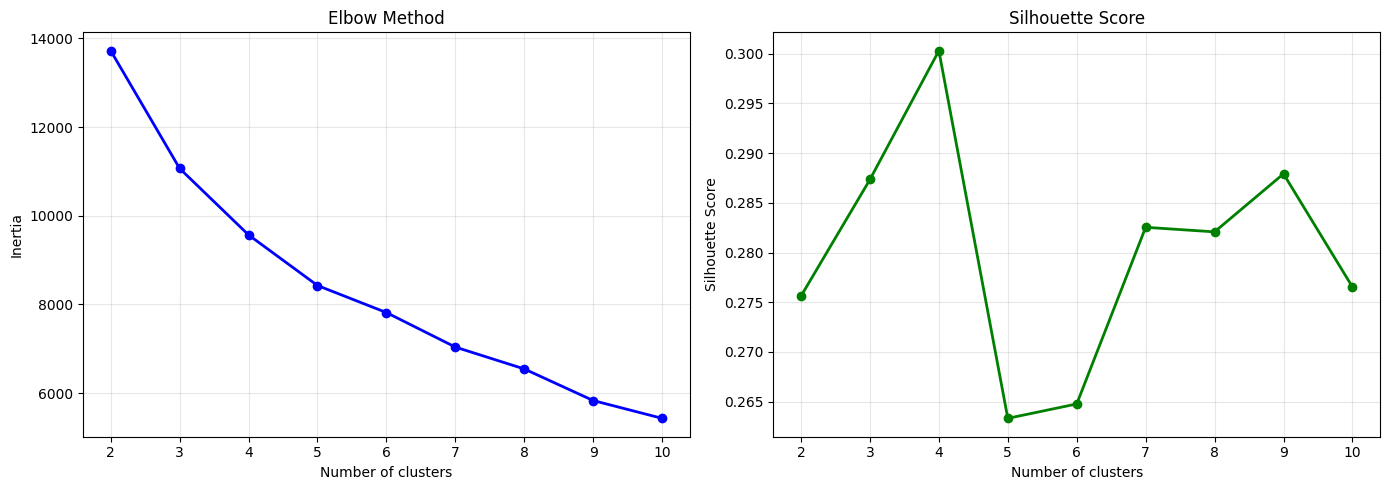

In [3]:
inertias     = []
silhouettes  = []
K_range      = range(2, 11)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(clustered_data)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(clustered_data, km.labels_))
    print(f'K={k}  Inertia={km.inertia_:.2f}  Silhouette={silhouettes[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(K_range), inertias, 'bo-', linewidth=2)
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_range), silhouettes, 'go-', linewidth=2)
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


  Cluster 0: 638 transactions (28.7%)
  Cluster 1: 1078 transactions (48.4%)
  Cluster 2: 474 transactions (21.3%)
  Cluster 3: 36 transactions (1.6%)

What each cluster represents in real KES values:
         num_transactions  avg_amount_KES  min_amount_KES  max_amount_KES  \
cluster                                                                     
0                     638          357.18            40.0          3240.0   
1                    1078         3011.78            40.0          9984.4   
2                     474         2904.46            40.0          8000.0   
3                      36         9355.56           920.0         46880.0   

         pct_weekend  
cluster               
0               0.18  
1               0.00  
2               1.00  
3               0.28  


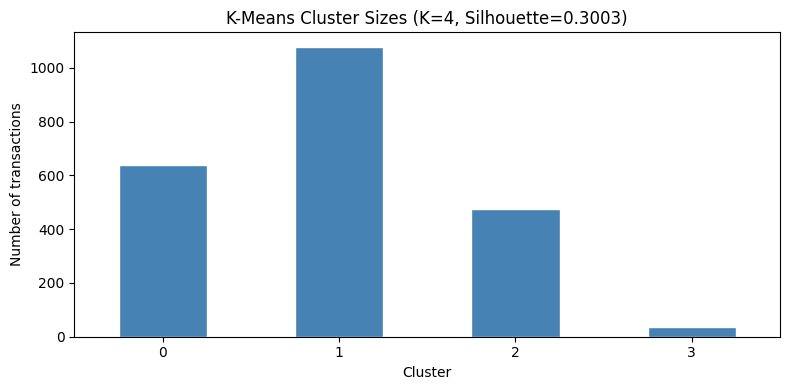

Saved: kmeans_model.pkl


In [4]:
# Update this after looking at the charts above
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans.fit(clustered_data)

sil_score = silhouette_score(clustered_data, kmeans.labels_)


# Cluster sizes
cluster_sizes = pd.Series(kmeans.labels_).value_counts().sort_index()
print()
for cluster, count in cluster_sizes.items():
    print(f'  Cluster {cluster}: {count} transactions ({count/len(kmeans.labels_)*100:.1f}%)')

# Cluster summary in real KES values
clustered_data_raw['cluster'] = kmeans.labels_
cluster_summary = clustered_data_raw.groupby('cluster').agg(
    num_transactions = ('amount', 'count'),
    avg_amount_KES   = ('amount', 'mean'),
    min_amount_KES   = ('amount', 'min'),
    max_amount_KES   = ('amount', 'max'),
    pct_weekend      = ('is_weekend', 'mean')
).round(2)

print()
print('What each cluster represents in real KES values:')
print(cluster_summary)

# Bar chart
cluster_sizes.plot(kind='bar', figsize=(8, 4),
    title=f'K-Means Cluster Sizes (K={OPTIMAL_K}, Silhouette={sil_score:.4f})',
    color='steelblue', edgecolor='white')
plt.xlabel('Cluster')
plt.ylabel('Number of transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

joblib.dump(kmeans, 'kmeans_model.pkl')
print('Saved: kmeans_model.pkl')

# Isolation




Isolation Forest trained.
Normal transactions:    2114
Anomalous transactions: 112 (5.0%)
Score range: -0.1181 to 0.1530

Top 10 most anomalous transactions:
       amount  anomaly_score
1716  26160.0      -0.118089
2065  45160.0      -0.116382
0      1600.0      -0.110996
2225   4560.0      -0.108228
1593  46240.0      -0.105461
2022  18280.0      -0.105267
2118  34160.0      -0.102733
2174  11960.0      -0.094501
2049  12520.0      -0.092716
1766   5560.0      -0.091954


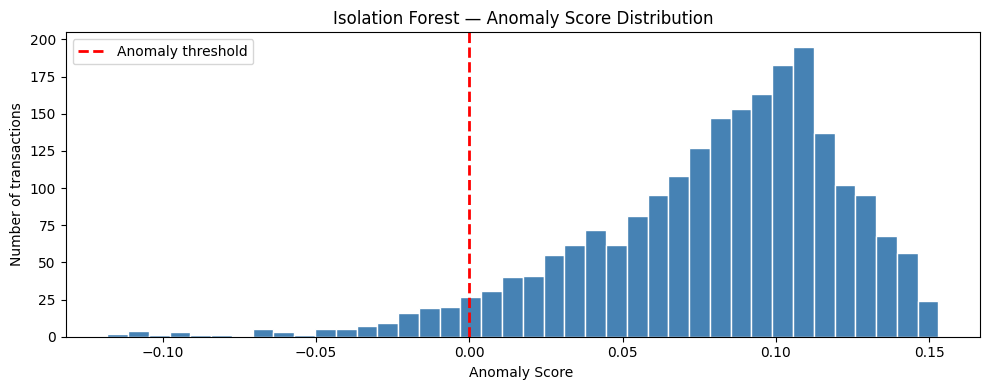

Saved: isolation_forest_model.pkl


In [5]:
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(clustered_data)

predictions = iso_forest.predict(clustered_data)
scores = iso_forest.decision_function(clustered_data)

n_anomalies = (predictions == -1).sum()
n_normal = (predictions ==  1).sum()

print(f'Isolation Forest trained.')
print(f'Normal transactions:    {n_normal}')
print(f'Anomalous transactions: {n_anomalies} ({n_anomalies/len(predictions)*100:.1f}%)')
print(f'Score range: {scores.min():.4f} to {scores.max():.4f}')
print()

# Show flagged transactions
clustered_data_raw['anomaly_score'] = scores
clustered_data_raw['is_anomaly']    = (predictions == -1).astype(int)

top_anomalies = clustered_data_raw[
    clustered_data_raw['is_anomaly'] == 1
].sort_values('anomaly_score').head(10)

print('Top 10 most anomalous transactions:')
print(top_anomalies[['amount', 'anomaly_score']].to_string())

# Histogram
plt.figure(figsize=(10, 4))
plt.hist(scores, bins=40, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Anomaly threshold')
plt.xlabel('Anomaly Score ')
plt.ylabel('Number of transactions')
plt.title('Isolation Forest — Anomaly Score Distribution')
plt.legend()
plt.tight_layout()
plt.show()

joblib.dump(iso_forest, 'isolation_forest_model.pkl')
print('Saved: isolation_forest_model.pkl')

In [6]:
features_prediction = [
    'total_spend',
    'transaction_count',
    'avg_transaction',
    'max_transaction',
    '4week_avg',
    '4week_max',
    'spend_vs_avg',
    'week_of_month_num'
]

mean_spend  = weekly['total_spend'].mean()
std_spend   = weekly['total_spend'].std()
upper_limit = mean_spend + 2 * std_spend

weekly_clean = weekly[
    weekly['total_spend'] < upper_limit
].copy()

weekly_clean['next_week_spend'] = weekly_clean['total_spend'].shift(-1)
weekly_clean = weekly_clean.dropna(subset=['next_week_spend'])

X = weekly_clean[features_prediction]
y = weekly_clean['next_week_spend']

scaler_prediction = StandardScaler()
X_scaled = scaler_prediction.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2, random_state=42, shuffle=False
)

joblib.dump(scaler_prediction, 'scaler_prediction.pkl')

['scaler_prediction.pkl']

# Random Forest

RANDOM FOREST REGRESSION
Training weeks: 78
Test weeks: 20
RMSE: KES 25377.18
R²: -1.7897 (-179.0%)

Negative R² — high spending variance limits prediction accuracy.


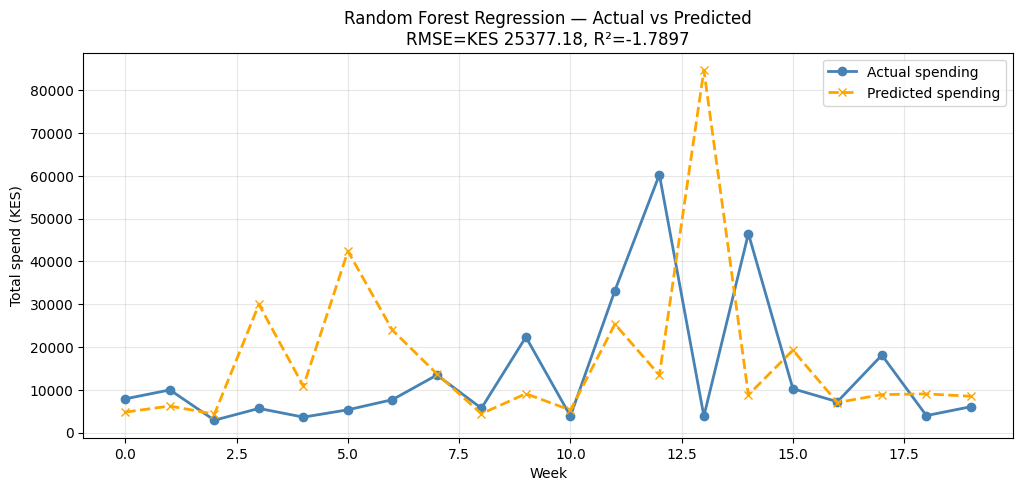

['random_forest_model.pkl']

In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=3,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print('RANDOM FOREST REGRESSION')
print(f'Training weeks: {X_train.shape[0]}')
print(f'Test weeks: {X_test.shape[0]}')
print(f'RMSE: KES {rmse_rf:.2f}')
print(f'R²: {r2_rf:.4f} ({r2_rf*100:.1f}%)')
print()
if r2_rf > 0.5:
    print('Strong predictive performance.')
elif r2_rf > 0.2:
    print('Moderate predictive performance.')
elif r2_rf > 0:
    print('Weak but positive — model is learning something.')
else:
    print('Negative R² — high spending variance limits prediction accuracy.')

plt.figure(figsize=(12, 5))
plt.plot(range(len(y_test)), y_test.values,
         label='Actual spending', marker='o',
         linewidth=2, color='steelblue')
plt.plot(range(len(y_pred_rf)), y_pred_rf,
         label='Predicted spending', marker='x',
         linestyle='--', linewidth=2, color='orange')
plt.xlabel('Week')
plt.ylabel('Total spend (KES)')
plt.title(f'Random Forest Regression — Actual vs Predicted\n'
          f'RMSE=KES {rmse_rf:.2f}, R²={r2_rf:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

joblib.dump(rf, 'random_forest_model.pkl')

# Linear Regression

LINEAR REGRESSION
Training weeks: 78
Test weeks: 20
RMSE: KES 15170.13
R²: 0.0031 (0.3%)

Weak but positive — model is learning something.


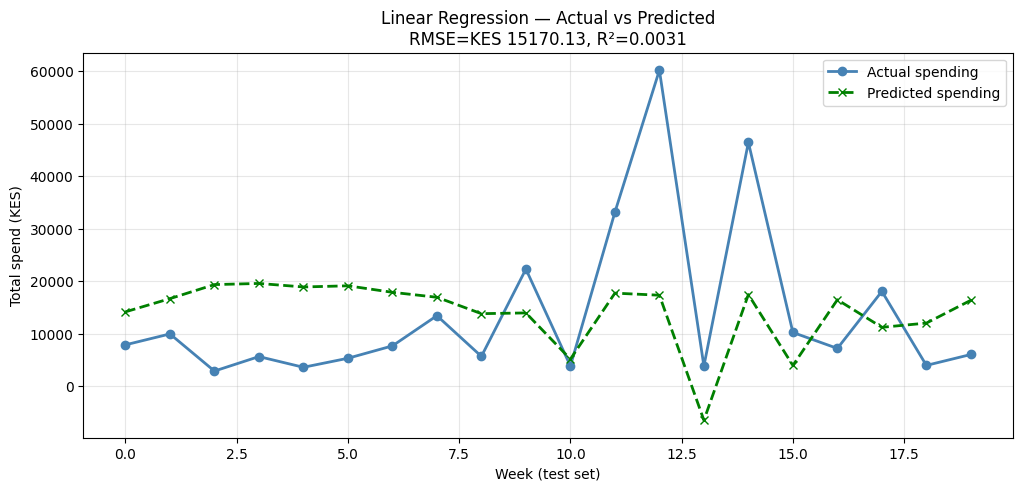

['linear_regression_model.pkl']

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print('LINEAR REGRESSION')
print(f'Training weeks: {X_train.shape[0]}')
print(f'Test weeks: {X_test.shape[0]}')
print(f'RMSE: KES {rmse_lr:.2f}')
print(f'R²: {r2_lr:.4f} ({r2_lr*100:.1f}%)')
print()
if r2_lr > 0.5:
    print('Strong predictive performance.')
elif r2_lr > 0.2:
    print('Moderate predictive performance.')
elif r2_lr > 0:
    print('Weak but positive — model is learning something.')
else:
    print('Negative R² — high spending variance limits prediction accuracy.')

plt.figure(figsize=(12, 5))
plt.plot(range(len(y_test)), y_test.values,
         label='Actual spending', marker='o',
         linewidth=2, color='steelblue')
plt.plot(range(len(y_pred_lr)), y_pred_lr,
         label='Predicted spending', marker='x',
         linestyle='--', linewidth=2, color='green')
plt.xlabel('Week (test set)')
plt.ylabel('Total spend (KES)')
plt.title(f'Linear Regression — Actual vs Predicted\n'
          f'RMSE=KES {rmse_lr:.2f}, R²={r2_lr:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

joblib.dump(lr, 'linear_regression_model.pkl')

In [9]:
print('K-MEANS CLUSTERING')
print(f'Clusters (K): {kmeans.n_clusters}')
print(f'Silhouette Score: {sil_score:.4f}')
print()
print('ISOLATION FOREST')
print(f'Total transactions: {len(predictions)}')
print(f'Anomalies detected: {n_anomalies} ({n_anomalies/len(predictions)*100:.1f}%)')
print(f'Score range: {scores.min():.4f} to {scores.max():.4f}')
print()
print('RANDOM FOREST REGRESSION')
print(f'RMSE: KES {rmse_rf:.2f}')
print(f'R²: {r2_rf:.4f}')
print()
print('LINEAR REGRESSION')
print(f'RMSE: KES {rmse_lr:.2f}')
print(f'R²: {r2_lr:.4f}')


K-MEANS CLUSTERING
Clusters (K): 4
Silhouette Score: 0.3003

ISOLATION FOREST
Total transactions: 2226
Anomalies detected: 112 (5.0%)
Score range: -0.1181 to 0.1530

RANDOM FOREST REGRESSION
RMSE: KES 25377.18
R²: -1.7897

LINEAR REGRESSION
RMSE: KES 15170.13
R²: 0.0031
